# 📚 Binder Yarn Segmentation  with SAM2



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/choROPeNt/segment-anything-2/blob/dev/notebooks/colab_analysis_binder.ipynb)

## 🌍 Environment Set-up
If running locally using jupyter, first install `SAM 2` in your environment using the installation instructions in the repository.

If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'.
> Note that it's recommended to use **L4 GPUs when running in Colab** (T4 GPUs might also work, but could be slow and might run out of memory in some cases e.g. training).

In [1]:
using_colab = False # set to False if you are not working on Google Colab

### 📦 Load Packages

If you are on Google Colab some packages have to be installed that might take up to 5 min. Grab a a Coffe ☕️

❗️**THE FOLOWING CELL HAS TO BE EXECUTED TO LOAD ALL NECESSARY PACKAGES**❗️



In [5]:
%%capture
# --- Packages --
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage.measure import regionprops_table, regionprops
import pandas as pd
from tqdm.auto import tqdm
from time import time

# ===========================================================
#                Google Colab Setup (optional)
# ===========================================================
if using_colab:
    # Install required packages
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/choROPeNt/segment-anything-2.git@dev'

    # Download example images
    !mkdir -p ./images/
    !wget -P ./images/ "https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/image_cfrp.tiff"
    !wget -P ./images/ "https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/image_gfrp.tiff"
    !wget -P ./images/ "https://raw.githubusercontent.com/choROPeNt/segment-anything-2/dev/images/panorama.tif"

    # Download SAM2 model checkpoint
    !mkdir -p ./checkpoints/
    !wget -P ./checkpoints/ "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt"
else:
    import sam2
    from sam2.addons import *


## 🏎️ Device Selection

PyTorch currently supports the following hardware acceleration backends and are recommended:

- **CUDA** — NVIDIA GPU acceleration (Linux and Windows)
- **MPS** — Metal Performance Shaders for Apple Silicon (macOS)
- **ROCm** — AMD GPU acceleration (Linux)

Other backends such as **XPU** (Intel) or **TPU** (Google Cloud) require separate extensions and are not part of the core PyTorch package.

| Backend    | Platform    |  PyTorch support   |  Notes   |
| --- | --- | --- | --- |
| `CUDA `   |  Linux / Windows   |  ✅ Fully supported   |  Standard GPU backend for NVIDIA cards.   |   
| `MPS`    |   macOS (Apple Silicon or AMD GPUs)  |  ✅ Supported (since 1.12)   |  Uses Apple Metal; some ops may still fall back to CPU. Some numerical differences to `CUDA`  |     
|  `ROCm`   |   Linux (AMD GPUs)  |  ✅ Supported (since 1.10, stable ≥ 1.12)   |  Official ROCm builds available from PyTorch.org.   |     
|   `XPU / SYCL`  |  Intel GPUs   |  🧪 Experimental   |  Via Intel Extension for PyTorch (not in core).   |    
|  `TPU`   |  Cloud (Google Colab `TPU` VMs)   |  ❌ Not in core PyTorch   |   Requires torch_xla separately.  |    





























In [6]:
# -----------------------------------------------------------
# Select device (CUDA → MPS → CPU)
# -----------------------------------------------------------

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # fallback for unsupported ops
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using PyTorch Version {torch.__version__}")
print(f"Using device: {device}")

# -----------------------------------------------------------
# CUDA-specific optimizations
# -----------------------------------------------------------
if device.type == "cuda":
    # Enable bfloat16 autocast for entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

    # Enable TensorFloat-32 (TF32) on Ampere or newer GPUs
    props = torch.cuda.get_device_properties(0)
    if props.major >= 8:  # Ampere or newer
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

# -----------------------------------------------------------
# MPS warning (Apple Silicon)
# -----------------------------------------------------------
elif device.type == "mps":
    print(
        "\n⚠️  Warning: MPS support in PyTorch is still experimental.\n"
        "    SAM2 is trained on CUDA and may produce slightly different\n"
        "    numerical results or slower performance on MPS.\n"
        "    More details: https://github.com/pytorch/pytorch/issues/84936\n"
    )

Using PyTorch Version 2.10.0
Using device: mps

⚠️  Warning: MPS support in PyTorch is still experimental.
    SAM2 is trained on CUDA and may produce slightly different
    numerical results or slower performance on MPS.
    More details: https://github.com/pytorch/pytorch/issues/84936



#  1️⃣ Part 1: Single Image Analysis

## 💿 Load Image

**Note:**  
SAM2 expects images in the format **`[W, H, 3]`**, where the last dimension corresponds to the **RGB color channels**.

---

### 🖼️ Handling Different Image Modes (Pillow)

When loading images with **Pillow**, the image *mode* specifies how pixel values are represented:

| Mode | Meaning | Description |
|------|---------|-------------|
| **`"L"`** | 8-bit grayscale | One channel with values in **[0–255]**. |
| **`"I"`** | 32-bit grayscale (integer) | One channel, often used in scientific TIFFs; can store large dynamic ranges. |
| **`"I;16"`** | 16-bit grayscale (unsigned integer) | Common in microscopy and CT data; pixel values in **[0–65535]**. |
| **`"RGB"`** | Red–Green–Blue | Standard 3-channel color image. |
| **`"RGBA"`** | RGB + Alpha | 4 channels, includes transparency. |

To ensure compatibility with SAM2, images are always converted to **RGB**:

- `"L"`, `"I"`, or `"I;16"` → converted to RGB by duplicating the grayscale channel  
- `"RGBA"` → alpha channel removed and converted to RGB  

This ensures the consistent format **`W × H × 3`** required by SAM2.

---

### 🧮 Accepted Bit Depths

SAM2 accepts:

- **8-bit images** (0–255)
- **16-bit images** (0–65535)
- **32-bit integer** grayscale images

During preprocessing, SAM2 automatically:

- converts arrays to **float32**
- normalizes values to **[0, 1]**  
- downscales images larger than **1024 × 1024** (aspect ratio preserved)
- upsamples segmentation masks back to the original resolution

---

### 📁 Loading Your Own Image

You can upload an image using the file navigator on the left:

- **Google Colab:** uploaded images appear under `/content/images/`
- **Local environment:** the working directory is the folder containing this notebook

Please update the `file_path` variable accordingly 🚀


In [10]:

if using_colab:
    from google.colab import files

    uploaded = files.upload()

    if uploaded:
        file_path = list(uploaded.keys())[0]
    else:
        print("No file uploaded, using example image")
        # File path
        file_path = "/content/drive/MyDrive/PP15_15_100x copy3.jpg"
else:
    file_path = "../data/AMHaWer/Mikroskopie-UD_OV_P1/Prozess_00066_Uebersicht_x20_b.vsi" # <--- if working locally specify filepath

print(f"Using file_path:\n{file_path}")

Using file_path:
../data/AMHaWer/Mikroskopie-UD_OV_P1/Prozess_00066_Uebersicht_x20_b.vsi


In [11]:
meta, _ = read_vsi(file_path,scene="Acquisition", load_image=False)

print(meta)

for scene in meta["scenes"]:
    meta_scene, _ = read_vsi(file_path, scene=scene, load_image=False)
    print(scene, meta_scene["shape"])

SLF4J: No SLF4J providers were found.
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See https://www.slf4j.org/codes.html#noProviders for further details.


{'file_path': '../data/AMHaWer/Mikroskopie-UD_OV_P1/Prozess_00066_Uebersicht_x20_b.vsi', 'dims_order': '<Dimensions [T: 1, C: 1, Z: 1, Y: 7453, X: 90038]>', 'shape': (1, 1, 1, 7453, 90038), 'dtype': 'uint8', 'physical_pixel_sizes': {'X': 0.2930177661400994, 'Y': 0.2930177661400994, 'Z': None, 'unit': 'µm (usually)'}, 'scenes': ['Acquisition', 'Prozess_00066_Uebersicht_x20_b.vsi #2', 'Prozess_00066_Uebersicht_x20_b.vsi #3', 'Prozess_00066_Uebersicht_x20_b.vsi #4', 'Prozess_00066_Uebersicht_x20_b.vsi #5', 'Prozess_00066_Uebersicht_x20_b.vsi #6', 'Prozess_00066_Uebersicht_x20_b.vsi #7', 'Prozess_00066_Uebersicht_x20_b.vsi #8', 'Prozess_00066_Uebersicht_x20_b.vsi #9', 'macro image'], 'current_scene': 'Acquisition', 'channels': [np.str_('Channel:0:0')], 'ome': {'size_x': 90038, 'size_y': 7453, 'size_z': 1, 'size_c': 1, 'size_t': 1, 'pixel_type': 'PixelType.UINT8'}, 'bioformats_raw_metadata': OME(
   instruments=[<1 field_type>],
   images=[<10 field_type>],
)}
Acquisition (1, 1, 1, 7453, 90

In [17]:
scene_selection = "Prozess_00066_Uebersicht_x20_b.vsi #4"

meta_, img_ = read_vsi(file_path,scene=scene_selection,load_image=True)

In [18]:

# img_ shape: (t, c, z, y, x) — extract frame at t=0, z=0 → (c, y, x)
frame = img_[0, :, 0]

# Normalize to (H, W, 3) for SAM2
if frame.shape[0] == 1:       # single channel → repeat to RGB
    image_np = np.stack([frame[0]] * 3, axis=-1)
elif frame.shape[0] == 3:     # RGB → (y, x, 3)
    image_np = frame.transpose(1, 2, 0)
elif frame.shape[0] == 4:     # RGBA → drop alpha
    image_np = frame[:3].transpose(1, 2, 0)
else:                          # multi-channel → first 3
    image_np = frame[:3].transpose(1, 2, 0)

image_np = np.ascontiguousarray(image_np)

h, w, c = image_np.shape
print(f"Image shape: H {h}, W {w}, C {c}, dtype={image_np.dtype}")


Image shape: H 932, W 11255, C 3, dtype=uint8


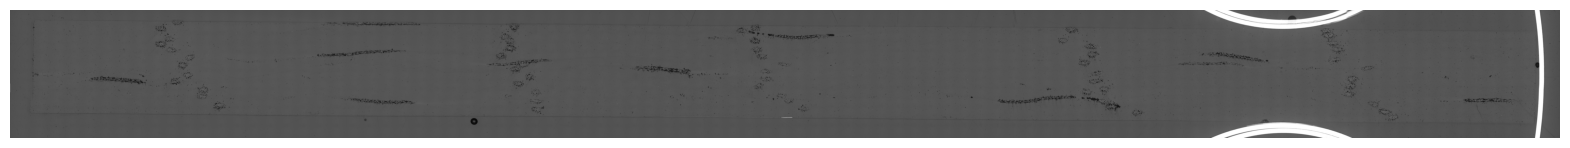

In [19]:
## Show the Image
plt.figure(figsize=(20, 4))
plt.imshow(image_np)
plt.axis('off')
plt.show()

## 🧩 Patch the Image

Large panoramic micrographs cannot be processed in a single pass without exceeding GPU memory.  
To handle this, we **tile (patch)** the input image into overlapping windows and later **stitch** the per-patch SAM2 detections back into a global instance map.

The `Sam2Patcher` helper takes care of:

- **Tiling** the image into patches of size `patch_h × patch_w`
- Using **overlaps** (`overlap_h`, `overlap_w`) to avoid artifacts at patch borders.  
  This creates an effective **stride** of  
  $$
  \text{stride\_h} = \text{patch\_h} - \text{overlap\_h}, \quad
  \text{stride\_w} = \text{patch\_w} - \text{overlap\_w},
  $$
  ensuring that each region of the image is seen multiple times.  
  Overlaps help SAM2 maintain segmentation quality near patch boundaries and prevent discontinuities when stitching.

- Optionally **padding** images that are not divisible by the patch size, ensuring the entire image is processed without distortion.

- **Merging instances across tiles** based on their Intersection-over-Union (IoU).  
  This step is crucial because the same fiber may appear in two or more overlapping patches; the `merge_iou` threshold determines when two detections should be considered the same global instance.

Together, this tiling–stitching workflow enables high-resolution, memory-efficient segmentation of very large micrographs (including panoramas, stitched mosaics, and large CT slices) while preserving consistent instance IDs across the full field of view.

This enables scalable, high-resolution segmentation of large micrographs while keeping GPU memory usage under control and maintaining

In [20]:
from sam2.addons import Sam2Patcher

# Initialize tiler for 1024×1024 patches with 6.25% overlap
patcher = Sam2Patcher(
    patch_h=1024,
    patch_w=1024,
    overlap_h=64,
    overlap_w=64,
    pad_mode="constant",  # how to pad if image size is not divisible by patch size
    merge_iou=0.1         # IoU threshold to merge instances across neighboring patches
)

The tiling step returns three components:

1. **`patches`**  
   A list of image tiles, each typically of size `1024 × 1024 × 3` (unless trimmed at boundaries).  
   Each patch can be processed independently by SAM2, making it possible to segment very large images that wouldn't fit into GPU memory at once.

2. **`offsets`**  
   A list of `(y, x)` coordinates, one for each patch.  
   These indicate the **top-left position of each patch in the original panorama**, allowing us to later reconstruct a full-resolution global instance map by placing each segmented patch back into its original location.

3. **`padded_shape`**  
   The shape `(H, W, 3)` of the full padded image that the patches cover.  
   Padding is introduced only when the image dimensions are not exact multiples of the patch size.  
   This ensures full coverage without distortion or cropping.

Together, these outputs form the basis for a **tile → segment → stitch** pipeline:
- SAM2 is run on each patch independently.
- Results are merged using the offsets.
- The final stitched instance map reconstructs the entire panoramic micrograph with consistent IDs.

In [22]:
## Patching
patches, offsets, padded_shape = patcher.tile_numpy(image_np)
print(f"Tiled into {len(patches)} patches of shape {patches[0].shape}, \
      \npadded shape: {padded_shape}")

Tiled into 12 patches of shape (932, 1024, 3),       
padded shape: (932, 11255, 3)


### 🖼️ Display some random Patches

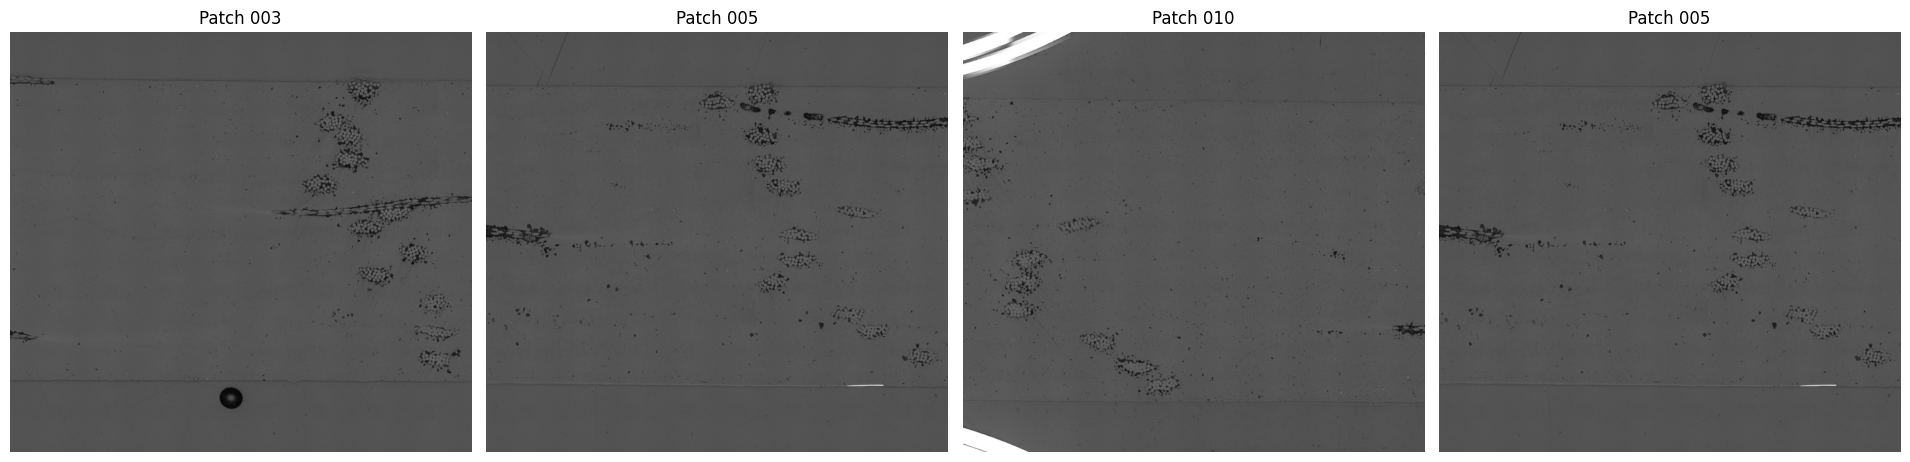

In [23]:
# Number of patches to display (max 4)
num_show = min(4, len(patches))

# Create figure
fig, axs = plt.subplots(
    1, num_show,
    figsize=(num_show * 4.8, 4.8)
)
axs = np.array(axs).ravel()  # ensure iterable

# Random visualization of patches and detections
for ax in axs:
    idx = np.random.randint(0, len(patches))

    ax.imshow(patches[idx])
    ax.set_title(f"Patch {idx:03d}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## ⚙️ Automatic mask generation
To run fully automatic segmentation, we first load a SAM 2 model checkpoint and then wrap it with the `SAM2AutomaticMaskGenerator`.  
This generator densely samples prompts over the image (e.g. a grid of points) and lets the model propose masks without any manual interaction.

### Steps

1. **Select a SAM 2 variant**  
   - The `model_cfg` points to a YAML config describing the architecture (e.g. `sam2.1_hiera_t`).
   - The `sam2_checkpoint` is the corresponding `.pt` weight file.  
   Make sure both paths match the same model variant.

2. **Build the SAM 2 model**  
   `build_sam2(model_cfg, sam2_checkpoint, device=device)` loads the model on the selected device (CPU, CUDA, or MPS).

3. **Configure the automatic mask generator**  
   The `SAM2AutomaticMaskGenerator` controls:
   - how densely prompts are sampled across the image (`points_per_side`),
   - GPU/memory usage (`points_per_batch`),
   - which masks are kept or filtered (`pred_iou_thresh`, `min_mask_region_area`, `box_nms_thresh`, `stability_score_thresh`).

These parameters let you trade off **speed vs. mask density** and **aggressiveness of filtering**.  
For micrographs with many fine structures (e.g. fibers, pores, defects), slightly higher `points_per_side` and lower thresholds often (`stability_score_thresh`, `pred_iou_thresh`, or `box_nms_thresh`) help capture more detailed masks.

In [31]:
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.addons import show_anns

# set here your checkpoint path and path to yourmodel cfg
if using_colab:
    sam2_checkpoint = "./checkpoints/sam2.1_hiera_tiny.pt"
else:
    sam2_checkpoint = "../checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)

mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2,                 # The preloaded SAM2 model used for automatic segmentation

    points_per_side=32,         # Sampling density of prompt points per image side.
                                # A higher value → more points → denser coverage, better for small or fine structures,
                                # but also slower and more memory-intensive.

    points_per_batch=48,        # Number of sampled points processed simultaneously by the model.
                                # Controls batch size; balance between speed and GPU memory usage.

    pred_iou_thresh=0.1,        # Minimum predicted IoU between the mask and its region proposal
                                # required to keep a candidate. Lower this to retain weaker (small or uncertain) masks.

    min_mask_region_area=10,    # Minimum area (in pixels) for a mask to be kept.
                                # Increasing this removes tiny specks; decreasing it helps keep very small objects.

    box_nms_thresh=0.3,         # Non-Maximum Suppression (NMS) threshold for filtering overlapping boxes.
                                # Lower values make the filter stricter, keeping fewer overlapping regions.

    stability_score_thresh=0.9  # Confidence threshold measuring mask consistency under perturbations.
                                # Lowering this (e.g. 0.7–0.8) retains more masks, especially smaller or noisier ones.
)

### ⚙️ Detection - Results
To generate masks, call the generate() function on an input image.

The returned object masks is a list of dictionaries, where each dictionary describes one detected region (e.g., a fiber cross-section). Each entry contains both the segmentation mask and associated metadata:

- `segmentation` : binary mask of the segmented region
- `area` : pixel area of the mask
- `bbox` : bounding box coordinates in the format `[x, y, width, height]`
- `predicted_iou` : model’s confidence estimate of segmentation accuracy (Intersection-over-Union (Jaccard) score)
- `point_coords` : coordinates of the prompt points used (if any)
- `stability_score` : measure of segmentation consistency under perturbations
- `crop_box` : image region from which the mask was generated

This output provides both the segmentation itself and useful metadata for filtering, analysis, or visualization.

In [40]:
def filter_by_area(detections, min_area=0, max_area=float("inf")):
    return [d for d in detections if min_area <= d["area"] <= max_area]


#----- Mask Generation -----
all_detections = []
for i, p in enumerate(tqdm(patches,
    total=len(patches),
    desc="Mask generation",
    unit="patch"
)):
    detections = mask_generator.generate(p)
    detections = filter_by_area(detections, min_area=200, max_area=5e3)
    print(f"detected {len(detections)} for patch {i:03d}")
    all_detections.append(detections)


Mask generation:   0%|          | 0/12 [00:00<?, ?patch/s]/Users/christian/Projects/segment-anything-2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/Users/christian/Projects/segment-anything-2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(
Mask generation:   8%|▊         | 1/12 [00:23<04:23, 23.93s/patch]

detected 1 for patch 000


Mask generation:  17%|█▋        | 2/12 [00:46<03:48, 22.90s/patch]

detected 10 for patch 001


Mask generation:  25%|██▌       | 3/12 [01:01<02:57, 19.68s/patch]

...

detected 5 for patch 009


Mask generation:  92%|█████████▏| 11/12 [03:16<00:17, 17.36s/patch]

detected 8 for patch 010


Mask generation: 100%|██████████| 12/12 [03:32<00:00, 17.70s/patch]

detected 2 for patch 011


In [41]:
for i, detections in enumerate(all_detections):
    areas = [d["area"] for d in detections]
    if areas:
        print(f"patch {i:03d} | n={len(areas):3d} | min={min(areas):6.0f}  max={max(areas):6.0f}  mean={sum(areas)/len(areas):6.0f}")
        print(areas)
    else:
        print(f"patch {i:03d} | no detections")


patch 000 | n=  1 | min=   305  max=   305  mean=   305
[305]
patch 001 | n= 10 | min=  2036  max=  3562  mean=  2493
[2036, 2655, 2453, 3562, 2324, 2764, 2746, 2118, 2233, 2038]
patch 002 | n=  1 | min=   286  max=   286  mean=   286
[286]
patch 003 | n= 12 | min=   953  max=  2961  mean=  2141
[1940, 2230, 2574, 2377, 2961, 2077, 2477, 1564, 953, 2069, 2306, 2160]
patch 004 | n=  2 | min=   863  max=  1452  mean=  1158
[1452, 863]
patch 005 | n= 19 | min=   247  max=  4458  mean=  2018
[1863, 4458, 2421, 2045, 2097, 2468, 2180, 1979, 1697, 687, 1964, 1820, 2797, 1848, 247, 653, 1708, 4074, 1328]
patch 006 | n=  4 | min=   672  max=  4800  mean=  2359
[996, 4800, 2967, 672]
patch 007 | n=  3 | min=   206  max=  2951  mean=  1752
[2951, 2100, 206]
patch 008 | n= 12 | min=   248  max=  3908  mean=  2144
[2827, 538, 2602, 3054, 3908, 2418, 2286, 1111, 2876, 1403, 2458, 248]
patch 009 | n=  5 | min=  1547  max=  4395  mean=  2452
[1547, 1691, 1687, 4395, 2938]
patch 010 | n=  8 | min=   5

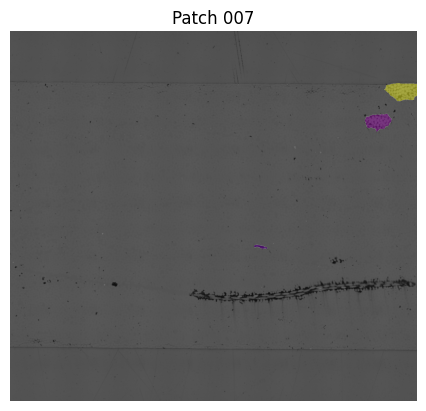

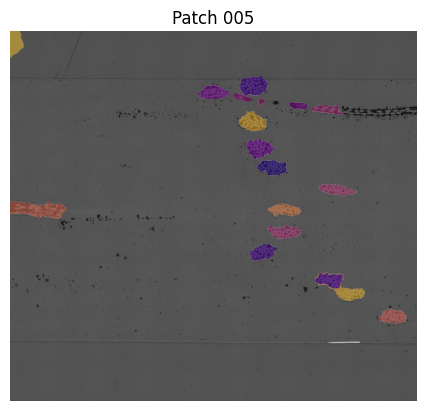

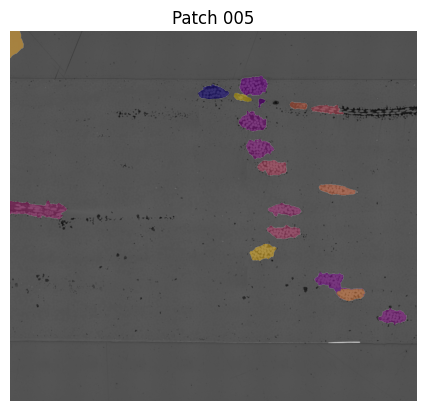

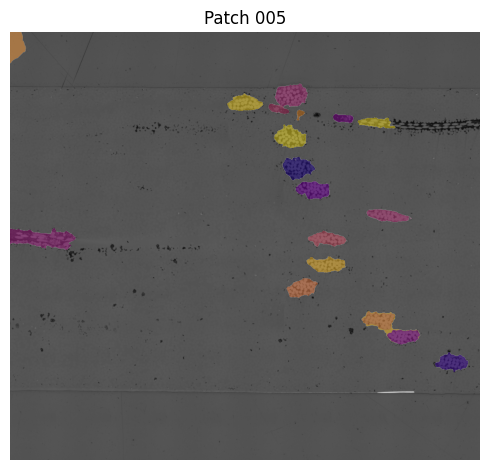

In [42]:
# Number of patches to display (max 4)
num_show = min(4, len(patches))

# Random visualization of patches and detections
for i in range(num_show):
    idx = np.random.randint(0, len(patches))
    plt.figure()
    plt.imshow(patches[idx])
    show_anns(all_detections[idx])
    plt.title(f"Patch {idx:03d}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 🪡 Stitching the Results

Once all patches have been processed individually, their local SAM2 detections must be merged back into a **single global instance map**.  
The `Sam2Patcher` handles this by aligning each patch’s detections using its offset and resolving overlaps using an IoU-based merging rule.

The output of this step consists of:

- **`label_map`**  
  A full-resolution 2D array where each pixel contains the **global instance ID** (0 = background).

- **`instances`**  
  A list of dictionaries, one per detected object in the entire panorama.  
  Each entry contains:
  - `"id"` — the unique global instance ID  
  - `"area"` — number of pixels belonging to the instance  
  - `"segmentation_crop"` — the boolean mask cropped to its bounding box for compact storage  
  - `"bbox"` — bounding box in `[x0, y0, width, height]` format (global coordinates)

This stitched output provides a unified and consistent segmentation map across the whole image, even when individual patches overlap or contain partial views of the same object.

In [43]:
# Stitch per-patch SAM2 detections into a global label map and instance list
label_map, instances = patcher.stitch_sam2_instances(
    padded_shape_hw=padded_shape[:2],  # (H, W) of the full (padded) canvas
    offsets=offsets,                   # top-left (y, x) coords of each patch
    per_tile_sam2=all_detections,      # list of SAM2 detections per patch
    debug=False,
)

### 🖼️ Display the Results for Panorama

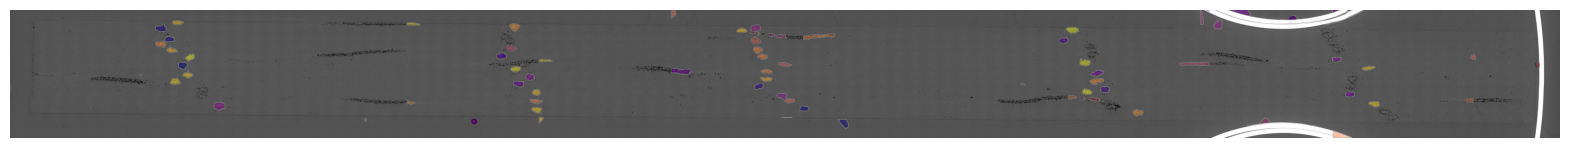

In [44]:
plt.figure(figsize=(20,4))
plt.imshow(image_np)
show_anns(instances)
plt.axis("off")
plt.show()